In [3]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# calibration
from sklearn.calibration import CalibratedClassifierCV

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback

#preprocessing 
from tensorflow.keras.preprocessing import image


import sys
from copy import deepcopy

import kagglehub
# =====================================


In [4]:
path = os.path.join(os.getcwd(), 'smart_grid_stability_augmented_dataset','smart_grid_stability_augmented.csv')
df = pd.read_csv(path)
print(df.columns.values)

['tau1' 'tau2' 'tau3' 'tau4' 'p1' 'p2' 'p3' 'p4' 'g1' 'g2' 'g3' 'g4'
 'stab' 'stabf']


### Lower triangular correlation heatmap


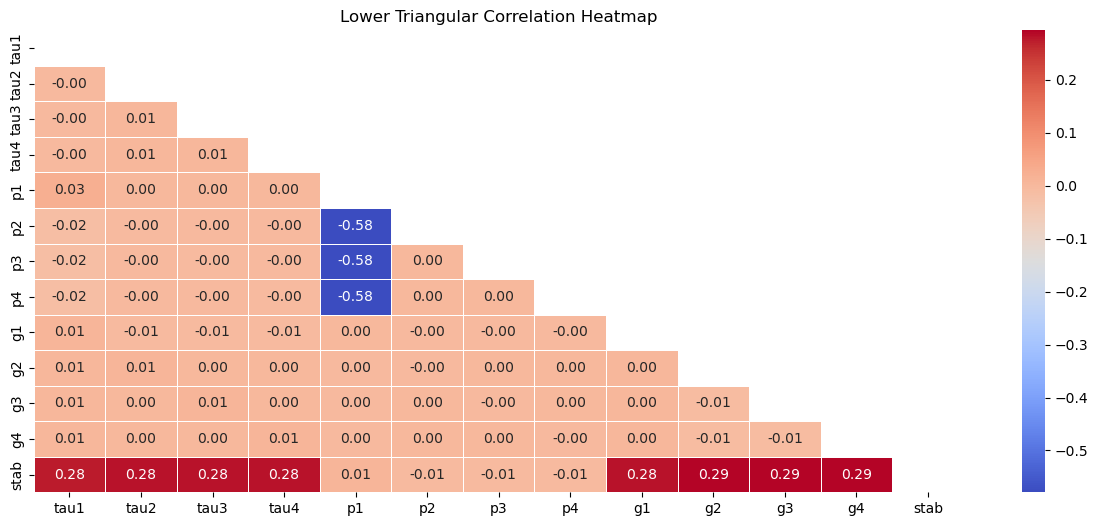

In [5]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(15, 6))

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap with mask
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,ax=ax)

plt.title("Lower Triangular Correlation Heatmap")
plt.show()

Lower triangular correlation heatmap that displays the ***Pearson correlation coefficients*** between various parameters of an electrical grid system simulation. The color intensity and value within each cell indicate the strength and direction of the linear relationship between the two corresponding variables.

### Regressor Independent variable and Definitions:

($\tau{x}$) (tau1-tau4): Power generator response times.p[x] 
- (p1-p4): Nominal power consumed (negative) or produced (positive).
- g[x] (g1-g4): Coefficients ($\gamma{(x)}$) proportional to price elasticity.
- stab: The maximal real part of the characteristic equation root. (A positive value indicates linear instability). 

#### Analysis of Correlations:

#### 1. Stability (stab) Correlations:

**Strong Positive Correlation**: stab has a strong positive correlation with the generator response times: ($\tau{1}$) to ($\tau{4}$) (all around 0.28-0.29). This means that as the generator response times increase (slower response), the **value of stab increases**. Since a positive stab value indicates instability, slower generator response times increase the likelihood of system instability.

**Weak/Negligible Correlation**: stab has very weak correlation (around 0.01) with the nominal power consumed/produced (p1 to p4) and the price elasticity coefficients (g1 to g4).

2. **Correlations Between Generator Response Times ($\tau{x}$)** The tau variables ($\tau{1}$) to ($\tau{4}$) show negligible correlation with each other (values around 0.00 to 0.02). This suggests these **four response times are largely independent of one another in the dataset**.

3. **Correlations with Nominal Power (p):** The nominal power variable p1 shows a strong negative correlation with p2, p3, and p4 (all around -0.57 or -0.58). This indicates that the ***power consumed or produced by generator 1 is inversely related to that of the other generators***.

4. **Correlations with Price Elasticity Coefficients (g):** The g variables (g1 to g4) **show negligible correlation with most other parameters**, except for a weak positive correlation among themselves (around 0.28-0.31 between g2, g3, and g4).

The most significant our finding in this heatmap is that slower generator response times (($\tau{x}$) variables) are directly associated with increased electrical grid instability (stab). Other parameters (p and g variables) appear to have little direct linear relationship with the stability metric shown here.

Now we see relations between responce time & grid condtions.

### Responce Time:
Response time in grid stability refers to how quickly a power system component—like a generator, battery, or inverter—reacts to disturbances to help maintain frequency, voltage, and overall system balance.

Compute Response Time


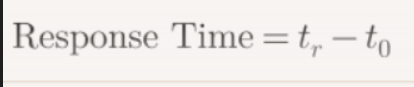

where t0 = start time of the disturbance.

tr = Identify the time, when the device begins to respond significantly (e.g., power output exceeds a threshold like 5% of rated capacity).

#### Plot Responce time and Grid Stability

Now  we are going to visualize the average value of a tau-x (responce time) and Grid stability conditions

Creates a bar plot using Seaborn that visualizes the mean and standard deviation of the tau1 variable for each category in stabf.

- Each bar represents the mean value of tau1 for a category in stabf.
- The height of the bar = mean of tau1
- The error bar = ±1 standard deviation
- Bars are colored by stabf, but since hue="stabf" matches x="stabf", each bar gets a unique color (but legend is hidden).

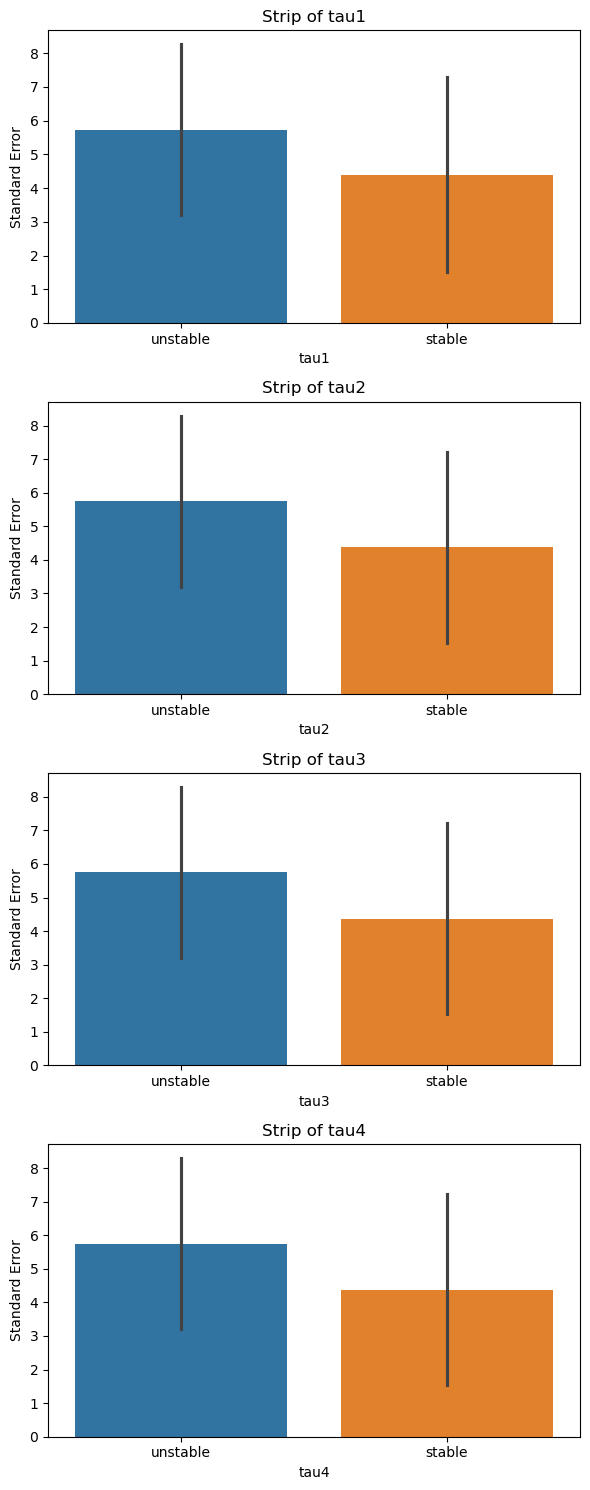

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.barplot(data=df, x='stabf', y = var,hue="stabf",errorbar='sd', legend=False,ax=axes[i])
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Standard Error")

plt.tight_layout()

#### creates a bar plot using Seaborn and then adds labels to each bar using Matplotlib

- Each bar represents the total value of tau1 for a category in stabf.
- Labels on top of each bar show the exact sum.
- No error bars are shown.
- Useful for visualizing aggregated totals rather than averages.

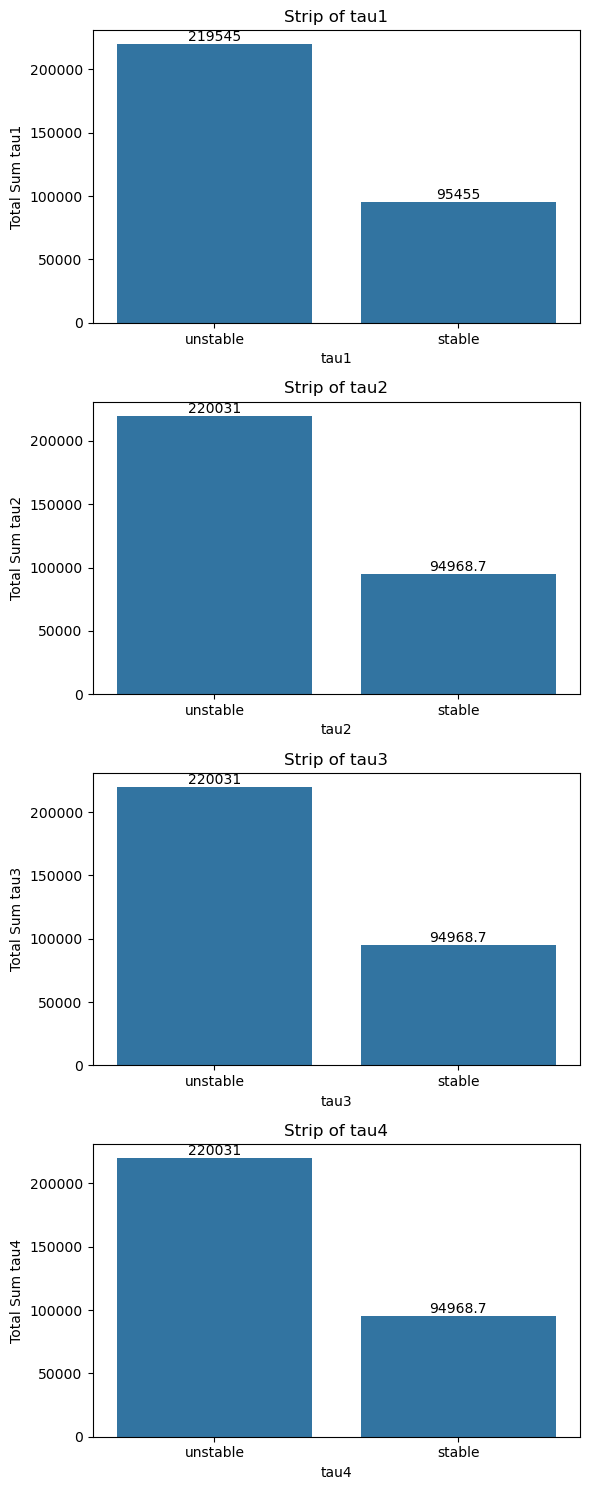

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    ax = sns.barplot(data=df, x='stabf', y = var,estimator="sum", legend=False,errorbar=None,ax=axes[i])
    ax.bar_label(ax.containers[0], fontsize=10);
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(f"Total Sum {var}")

plt.tight_layout()

This bar chart titled "Strip of tau1" compares the total sum of tau1 values between two categories: "unstable" and "stable". 

#### Chart Interpretation:

- X-axis (tau X(1/2/3/4)): Represents the two categories—unstable and stable.
- Y-axis (Total Sum tau1): Shows the cumulative sum of tau1 values for each category.
- Bar Heights:
- Unstable: ~36,590.8
- Stable: ~15,909.2

#### Final conclusions:

The unstable category has more than twice the total tau1 compared to the stable category. 
So we can conclude that higher tau1 values are associated with instability in the system.
We know that tau X represents a time of response, delay, or damping factor, this could imply:

- Systems with longer response times or slower dynamics tend to be unstable.
- Stability may require lower tau1 values, possibly indicating faster or more responsive behavior.

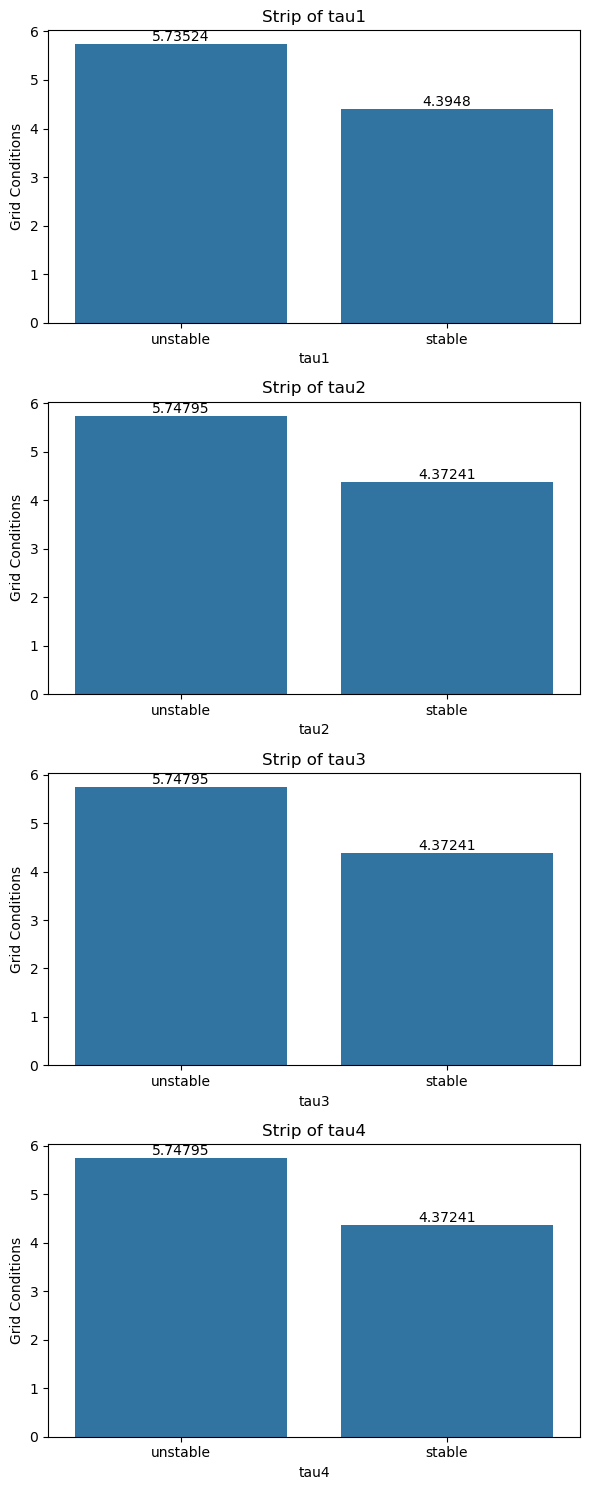

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    ax = sns.barplot(data=df, x='stabf', y = var,estimator="mean", legend=False,errorbar=None,ax=axes[i])
    ax.bar_label(ax.containers[0], fontsize=10);
    axes[i].set_title(f"Strip of {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Grid Conditions")

plt.tight_layout()

####  visualize the distribution of the tauX variable across categories in stabf

A violin plot combines a box plot and a kernel density estimate (KDE):
- The width of the violin at each y-value shows the density of data points.
- The center line shows the **median**.
- The box inside shows the interquartile **range (IQR)**.
- The tails extend to the **min and max values** (or a clipped range).

Q1 (25th percentile): [2.8748915690490775, 2.8750108529100626, 2.8750108529100626, 2.8750108529100626]
Q3 (75th percentile): [7.624689704807308, 7.624896226798954, 7.624896226798954, 7.624896226798954]
IQR (Q3 - Q1): <function iqr at 0x000002740F97DE40>
Median: [5.250003871926565, 5.249981261165705, 5.249981261165705, 5.249981261165705]
Min: [0.500793021360319, 0.500141360493773, 0.500141360493773, 0.500141360493773]
Max: [9.99946946943287, 9.99983655621537, 9.99983655621537, 9.99983655621537]


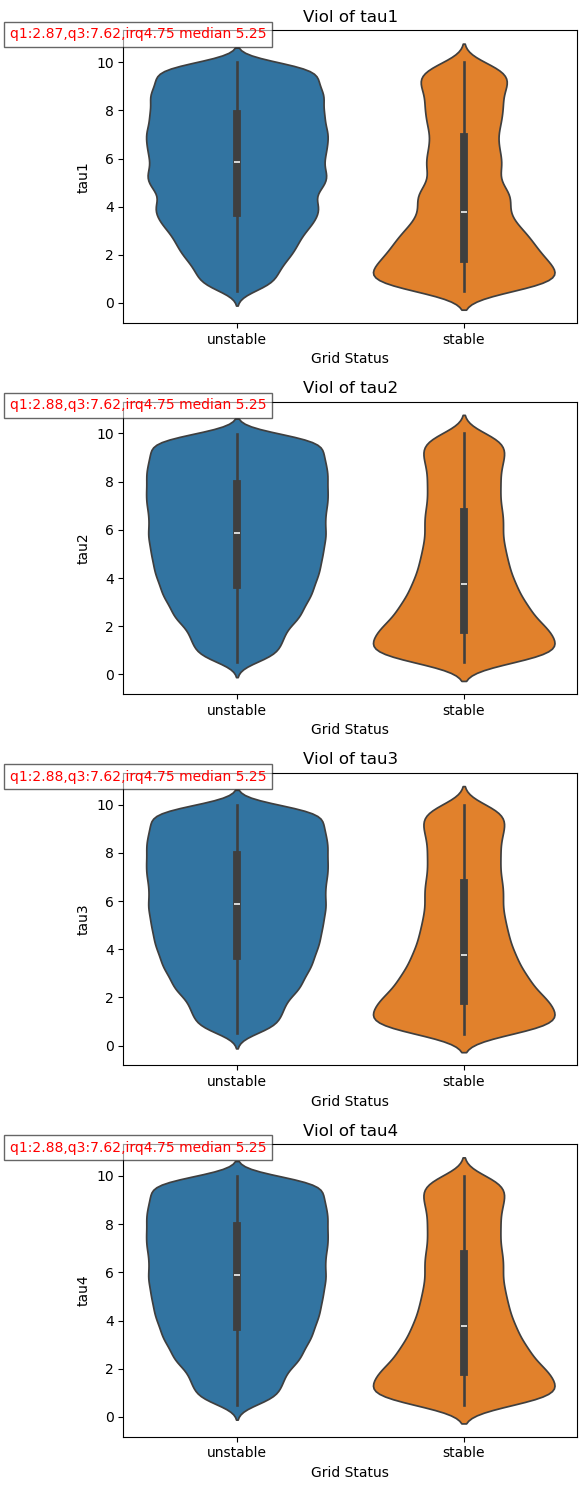

In [9]:
#sns.violinplot(data=df, x="stabf", y="tau1", hue="stabf", fill=True)

# Compute statistics
variables = ["tau1", "tau2", "tau3",'tau4']
q1 = []
q3 = []
irq = []
median  = []
min_val = []
max_val = []
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    q1.append(df[var].quantile(0.25))
    q3.append(df[var].quantile(0.75))
    irq.append((df[var].quantile(0.75) - df[var].quantile(0.25)))
    median.append(df[var].median())
    min_val.append(df[var].min())
    max_val.append(df[var].max())
# Display results
print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")
print(f"Median: {median}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.violinplot(data=df, x='stabf', y = var,hue='stabf',ax=axes[i])
    axes[i].set_title(f"Viol of {var}")
    axes[i].set_xlabel('Grid Status')
    axes[i].set_ylabel(var)
    q1 = (df[var].quantile(0.25))
    q3 = (df[var].quantile(0.75))
    irq = ((df[var].quantile(0.75) - df[var].quantile(0.25)))
    median = (df[var].median())
    min_val = (df[var].min())
    max_val = (df[var].max())
    axes[i].text(x=-1, y=11,
         s=f"q1:{round(q1,2)},q3:{round(q3,2)},irq{round(irq,2)} median {round(median,3)}",
         fontsize=10,color='red', bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()

Plot Type: A violin plot, which visualizes the distribution of numerical data (the y-axis) across different categories (the x-axis). The width of the shaded area represents the frequency or density of data points at that specific ($\tau{x}$) whered x = 1,2,3,4 value. 

The inner black bar and box indicate the interquartile range (IQR) and median.

### Analysis by Grid Status

**Unstable Grid Status (Left Violin, Blue):**

Distribution Shape: The distribution is wide and somewhat uniform across the entire range of ($\tau{x}$). It has a broad, almost heart-like shape. i.e. This suggests that a wide variety of response times for ($\tau{x}$) (from very fast near 0s to slower near 10s) frequently result in an **unstable grid system**. Instability is a common outcome across the full spectrum of observed ($\tau{x}$) values. The **median ($\tau{x}$)** value for unstable systems is around 5.3 seconds.

**Stable Grid Status (Right Violin, Orange):**

This distribution is **narrower and taller**, with distinct peaks around the median (approximately 3.5 to 4 seconds). It has a **more "pinched" or "hourglass" shape** compared to the unstable distribution. A stable grid status is associated with a more constrained range of ($\tau{x}$) values. Stability seems to be most likely when ($\tau{x}$) falls within a specific, narrower band of response times. Stable outcomes are less common than unstable ones (judging by the overall density comparison with a potentially larger dataset not fully visible here), and require specific, faster generator response times. 

Finally instability can happen with almost any generator response time ($\tau{x}$), stability is a more selective condition that predominantly occurs within a specific, narrower range of ($\tau{x}$) values (roughly between 2s and 7s), with a median lower than that of the unstable condition. 


#### Hist Plot of tau1 with Skew and Kurtosi - Analysis

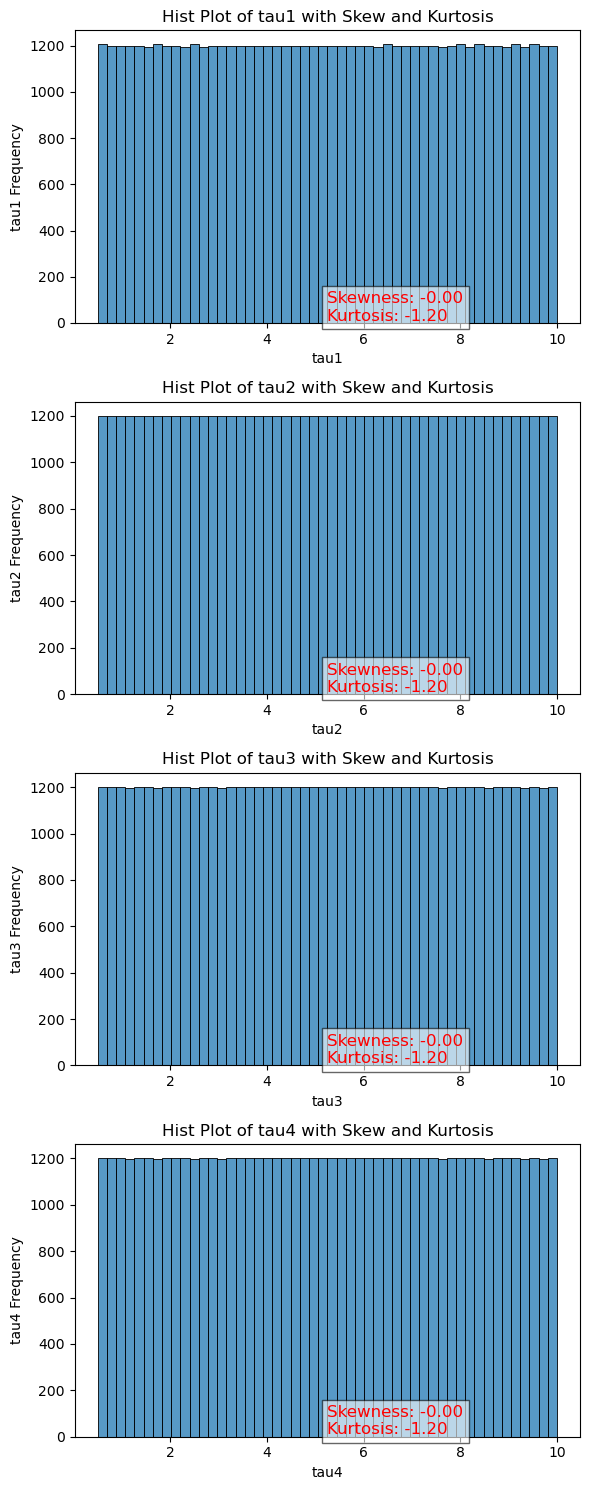

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(6, 15))
# Variables to plot
variables = ["tau1", "tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(variables):
    sns.histplot(data=df, x=var,bins=50, kde=False,ax=axes[i])
    # Calculate skewness and kurtosis
    skew_val = skew(df[var])
    kurt_val = kurtosis(df[var])  # Default is Fisher's definition (excess kurtosis)
    axes[i].set_title(f"Hist Plot of {var} with Skew and Kurtosis")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(var + ' Frequency')
    axes[i].text(x=df[var].mean(), y=10,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.tight_layout()

#### Hist Plot of tau1 with Skew and Kurtosi - Analysis

"Hist Plot of tau1 with Skew and Kurtosis" provides a visual and statistical summary of the distribution of the variable tau1.

#### Visual Interpretation:

- X-axis (tau1): Represents the range of values for the variable tau1, spanning from 0 to 10.
- Y-axis (tau1 Frequency): Indicates how many observations fall into each bin.
- Bars: The histogram shows a relatively uniform distribution—bars are nearly equal in height across the range, suggesting that tau1 values are evenly spread.

#### Statistical Annotations
- ***Skewness: −0.00:***
- This value is essentially zero, indicating a **perfectly symmetric distribution**.
- There's no noticeable lean to the left or right—tau1 is balanced around its center.
- ***Kurtosis: −1.20:***
- This is excess kurtosis, meaning it's measured relative to a **normal distribution** (which has kurtosis = 0).
- A negative value like −1.20 suggests a **platykurtic distribution**:
- Flatter peak
- Thinner tails
- Less extreme values than a normal distribution

#### Finals concusions:

- tau1 is uniformly distributed, both visually and statistically.
- It likely comes from a controlled or synthetic process where values are intentionally spread evenly.
- This kind of distribution is ideal for testing algorithms or modeling systems that require non-biased input.
- From a modeling perspective:
- You won’t need to transform tau1 for symmetry.
- It may not contribute much to predictive power unless it interacts with other variables.


#### Correlation matrix between responce time ($\tau{x}$)

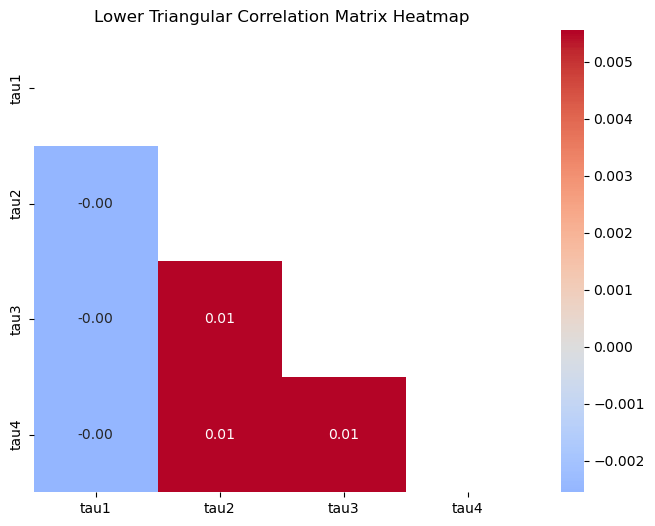

In [11]:
# Compute correlation matrix
dfTauParam = df.loc[:,['tau1','tau2','tau3','tau4']]
corr = dfTauParam.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Lower Triangular Correlation Matrix Heatmap")
plt.show()

#### Structure of the Heatmap

- Axes: Both x and y axes list the variables (tau1, tau2, tau3, tau4).
- Lower triangle only: The upper triangle is masked to avoid redundancy since correlation matrices are symmetric.

#### About Colors:
- Red shades → positive correlation
- Blue shades → negative correlation
- White/light → near zero correlation
- Annotations: Each cell contains the exact correlation coefficient

#### Correlation Values
- tau2 vs tau1: 0.02 → very weak positive correlation
- tau3 vs tau1: −0.01 → very weak negative correlation
- tau3 vs tau2: 0.01 → very weak positive correlation
- tau4 vs tau1: −0.02 → very weak negative correlation
- tau4 vs tau2: −0.00 → essentially no correlation
- tau4 vs tau3: 0.00 → no correlation

#### Result analysis
- All correlations are close to zero, meaning there is ***no strong linear relationship*** among tau1, tau2, tau3, and tau4.
- The **variables appear to be independent of each other** in terms of linear association.

- Each tau variable may represent distinct aspects of the system.
- **Multicollinearity is not a concern here** (good for regression modeling).
- If these are time constants or parameters, they are likely sampled independently.

The system seems designed or sampled to avoid overlap between these parameters. Response time are not correlate with each other. So they are linearly Independent and play very significant role in models.

- **Feature selectio**n: Since correlations are negligible, we can safely include all tau variables in a model without redundancy.

## Scatter plots, comparing the relationship between ($\tau{1}$) (x-axis) and t($\tau{x}$) (y-axis) under two different stability conditions

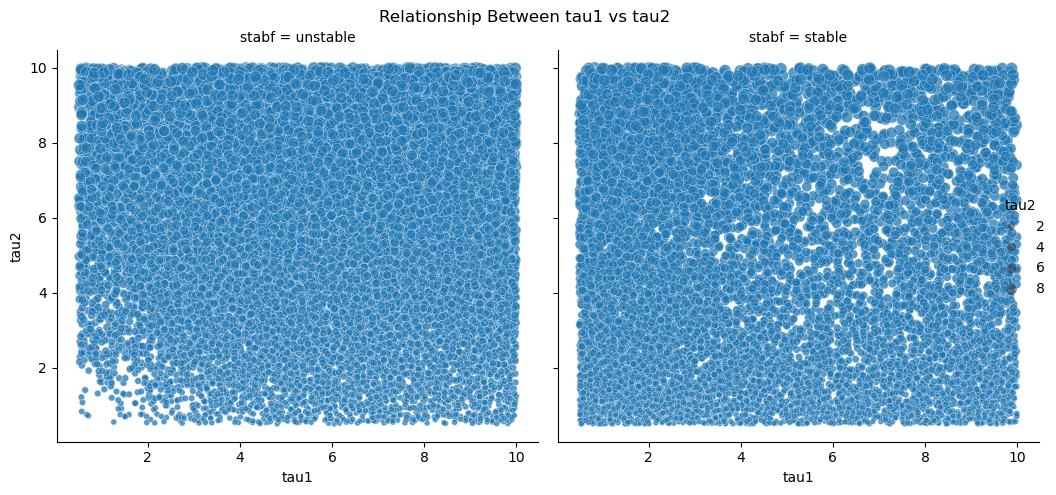

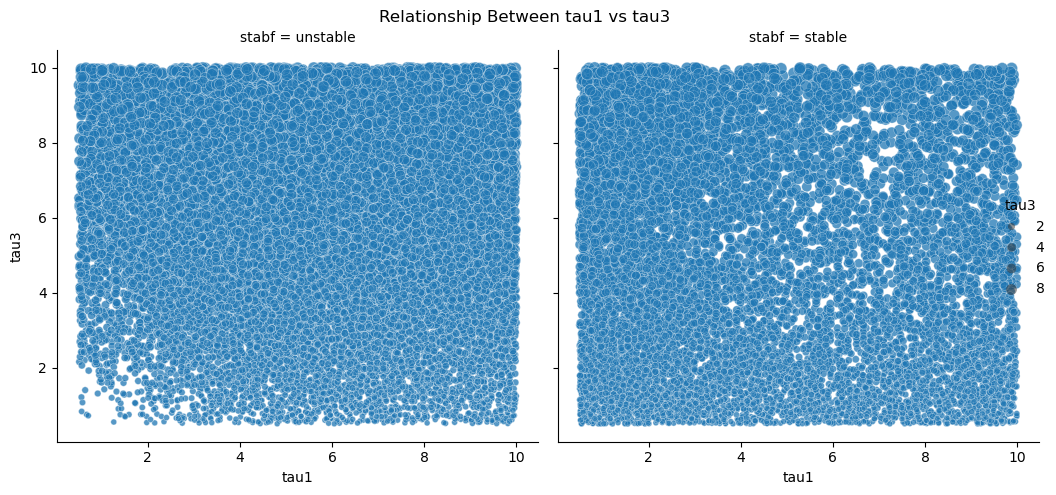

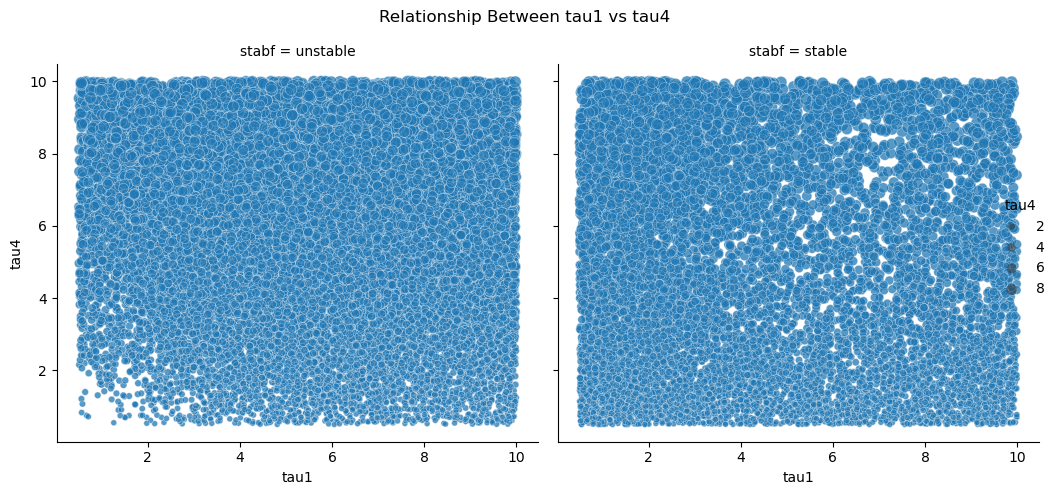

In [12]:
markers = {"stable": "s", "unstable": "X"}
#fig, axes = plt.subplots(3, 1, figsize=(6, 15))
# Variables to plot
var1 = 'tau1'
var2 = ["tau2", "tau3",'tau4']
# Loop through variables and plot each histogram
for i, var in enumerate(var2):    
    gx = sns.relplot(
    data=df, x=var1, y=var2[i],
    col="stabf",size = var2[i],
    kind="scatter",alpha = 0.5,markers=markers     
    )
    # Calculate skewness and kurtosis
    mean_var1 = df[var1].mean()
    variance_var1 = df[var1].var()  # Default is Fisher's definition (excess kurtosis)
    mean_var2 = df[var2[i]].mean()
    variance_var2 = df[var2[i]].var()
    # Set the overall title for the figure
    gx.fig.suptitle(f'Relationship Between {var1} vs {var2[i]}', fontsize=12)
    gx.fig.tight_layout()
    gx.fig.subplots_adjust(top=0.9)  # move title down a bit

    # Adjust the subplot parameters for a tight layout, making room for the title
    #g.fig.subplots_adjust(top=0.9) # Adjust the 'top' margin to prevent title overlap


    #axes[i].set_title(f"Scatter Plot of {var1} vs {var2[i]}")
    #axes[i].set_xlabel(var1)
    #axes[i].set_ylabel(var2[i])    
plt.tight_layout()

#### Scatter Plot analysis

This scatter plot illustrates the relationship between two time constants ($\tau{1}$) and ($\tau{x}$) wher x =2,3,4 and the resulting stability of an electrical grid system. 

The data points are split into two panels: one showing combinations of ($\tau{1}$) and ($\tau{x}$) that lead to an **unstable stat**e, and the other showing combinations that result in a **stable state**.

As specified, ($\tau{1}$) and ($\tau{x}$) represent the response times of power generators within the system. These time constants relate to how quickly different parts of the system react to disturbances.

**Unstable Region (Left Panel):** The left plot, labeled "stabf = unstable", shows that instability occurs across a wide range of values for both ($\tau{1}$) and ($\tau{x}$). The data points are densely distributed, suggesting that instability is the more common outcome when these parameters are randomly varied within the tested ranges (approximately 1 to 10 seconds).

**Stable Region (Right Panel):** The right plot, labeled "stabf = stable", shows the specific combinations of \($\tau{1}$) and ($\tau{x}$) where the system remains stable. Notably, the data points in this panel are much less dense than in the unstable panel, indicating that a stable condition is less frequent and likely constrained to a smaller, specific "stability domain" within the parameter space.

In the **unstable case**, there appears to be **no clear pattern or correlation** between ($\tau{1}$) and ($\tau{x}$); most combinations result in instability.

In the **stable case**, there appears to be a **slight negative correlation** as ($\tau{1}$) increases, higher values of ($\tau{x}$) become less common.

So we can conclude The plot highlights the challenge of maintaining power system stability. The system's ability to return to a balanced state after a ***disturbance is highly dependent on specific combinations of generator response times***, with many configurations leading to instability.

In both the stable and unstable conditions, there is a nearly perfect positive linear relationship between p1 and pAdd. The data points form a tight, straight line that goes from the bottom left to the top right of both graphs. So we can varify that 

p1 = p2+p3+p4

#### Trying to investigate co-related variable

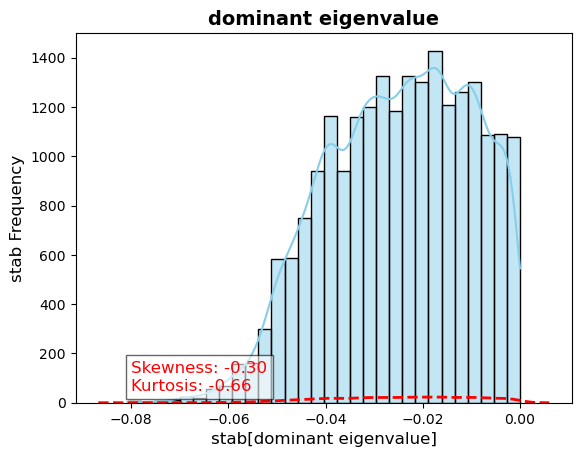

In [13]:
# Create histogram

dfStab = df[df['stabf'] == 'stable']
ax = sns.histplot(data=dfStab, x="stab", bins=30, color="skyblue", edgecolor="black",                  
                  kde=True)
sns.kdeplot(data=dfStab, x="stab", color="red", lw=2, linestyle="--", ax=ax)

# Set title and labels
ax.set_title("dominant eigenvalue", fontsize=14, weight="bold")
ax.set_xlabel("stab[dominant eigenvalue]", fontsize=12)
ax.set_ylabel("stab Frequency", fontsize=12)
skew_val = dfStab['stab'].skew()
kurt_val = dfStab['stab'].kurt()
ax.text(x=-0.08, y=50,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.show()


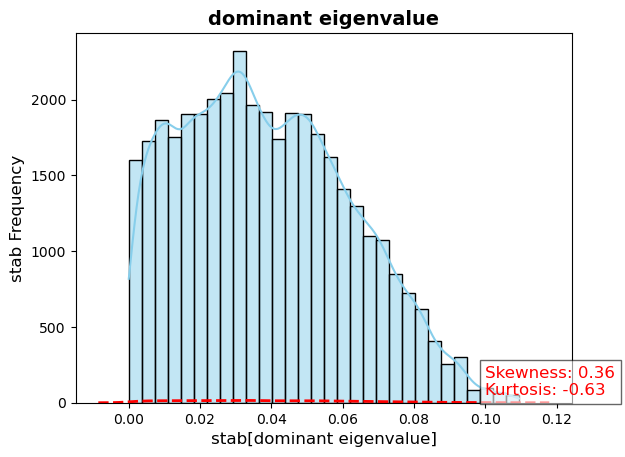

In [14]:
dfStab = df[df['stabf'] == 'unstable']
ax = sns.histplot(data=dfStab, x="stab", bins=30, color="skyblue", edgecolor="black",                  
                  kde=True)
sns.kdeplot(data=dfStab, x="stab", color="red", lw=2, linestyle="--", ax=ax)

# Set title and labels
ax.set_title("dominant eigenvalue", fontsize=14, weight="bold")
ax.set_xlabel("stab[dominant eigenvalue]", fontsize=12)
ax.set_ylabel("stab Frequency", fontsize=12)
skew_val = dfStab['stab'].skew()
kurt_val = dfStab['stab'].kurt()
ax.text(x=0.10, y=50,
         s=f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
         fontsize=12,color='red', bbox=dict(facecolor='white', alpha=0.6))
plt.show()

The dominant eigenvalue (stab) is the primary metric for system stability in power systems engineering. In this context:
- Positive stab values (as seen in this figure) indicate that the system is unstable.
- Negative stab values would indicate a stable system.

The distributions show that stable operations are centered around a specific negative eigenvalue, and unstable operations are centered around a specific positive eigenvalue. The visual separation implies that the system is highly sensitive to the parameters that push the dominant eigenvalue across the zero boundary.

**Left Plot (Stable):**
- Skewness: -0.30 (Slight negative skew; the tail extends slightly further into "more stable" negative values).
- Kurtosis: -0.66 (Platykurtic; slightly flatter than a standard normal distribution).

**Right Plot (Unstable):**
- Skewness: 0.36 (Slight positive skew; the tail extends slightly further into "more unstable" positive values).
- Kurtosis: -0.63 (Platykurtic; also slightly flatter than a standard normal distribution).

### Empirical Cumulative Distribution Function (ECDF)

Compares the distributions of the dominant eigenvalue (stab) for stable versus unstable scenarios in the electrical grid system.

<Axes: xlabel='stab', ylabel='Density'>

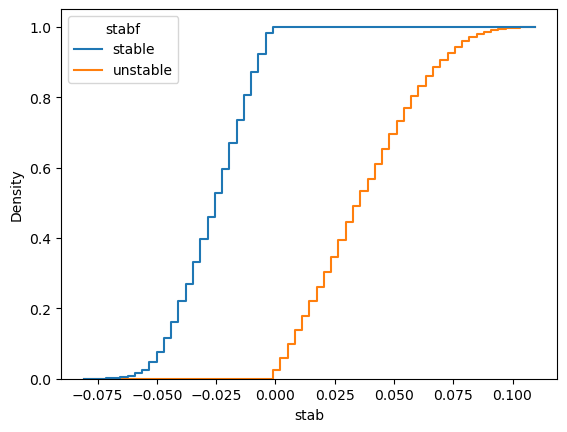

In [15]:
sns.histplot(
    data=df, x="stab", hue="stabf",
    hue_order=["stable", "unstable"],
    log_scale=False, element="step", fill=False,
    cumulative=True, stat="density", common_norm=False,
)

1. Stable Distribution (Blue Line):

- The blue line reaches a cumulative density of 1.0 exactly when stab reaches 0.000.
- This indicates that 100% of the data points classified as "stable" have a dominant eigenvalue less than or equal to 0.000.
- The steepest part of the curve occurs between stab values of -0.04 and 0.00, meaning most stable operations fall within this narrow range

2. Unstable Distribution (Orange Line):

- The orange line does not begin rising until stab reaches 0.000.
- It reaches a cumulative density of 1.0 near stab = 0.100.
- This indicates that 100% of the data points classified as "unstable" have a dominant eigenvalue greater than 0.000.

The figure visually confirms the definition of stability used in the dataset: any system configuration resulting in a dominant eigenvalue of zero or less is labeled stable, and any configuration resulting in an eigenvalue greater than zero is labeled unstable. The plot demonstrates a clean separation between the two distributions with no overlap across the stability boundary.

#### How dominant eigenvalue determining the stability of an electrical grid ?

The dominant eigenvalue of a power system’s state matrix determines grid stability because its real part indicates whether system oscillations decay or grow.

- If the **dominant eigenvalue has a negative real part**, **disturbances die out and the grid is stable**; 
- if **positive**, **oscillations amplify** and the grid becomes **unstable**.

In [16]:
dfStab = df[df['stabf'] == 'stable']
dfUnStab = df[df['stabf'] == 'unstable']
print(f'when grid stable, total dominant eigenvalue > 0 = {dfStab[dfStab['stab']>0].shape[0]}')
print(f'when grid stable, total dominant eigenvalue < 0 = {dfStab[dfStab['stab']<0].shape[0]}')
print(f'Mean value when grid stable: {dfStab['stab'].mean()}')

print(f'when grid un-stable, total dominant eigenvalue > 0 = {dfUnStab[dfUnStab['stab']>0].shape[0]}')
print(f'when grid un-stable, total dominant eigenvalue < 0 = {dfUnStab[dfUnStab['stab']<0].shape[0]}')
print(f'Mean value when grid un-stable: {dfUnStab['stab'].mean()}')

when grid stable, total dominant eigenvalue > 0 = 0
when grid stable, total dominant eigenvalue < 0 = 21720
Mean value when grid stable: -0.024798340318419296
when grid un-stable, total dominant eigenvalue > 0 = 38280
when grid un-stable, total dominant eigenvalue < 0 = 0
Mean value when grid un-stable: 0.03872711473046042


We can see Grid stable when  dominant eigenvalue <0.


### Role of Eigenvalues in Grid Stability

**System Representation**: 
- Electrical grids are modeled using differential equations that describe generator dynamics, inverter controls, and network interactions. These equations can be linearized into a state-space model.

**Eigenvalues of State Matrix:**
 - The eigenvalues of this matrix represent the **system’s natural modes of oscillation** (frequency and damping).

**Dominant Eigenvalue:**
- The eigenvalue with the largest real part (closest to zero or positive) is called the dominant eigenvalue.
- It dictates the slowest-decaying or fastest-growing mode, making it the most critical for stability assessment.

#### Example
Suppose a grid’s linearized state matrix yields eigenvalues:

![image.png](attachment:image.png)

The dominant eigenvalue acts like the “health indicator” of the grid’s dynamic response. 

Negative → safe and stable; 

positive → unstable and risky.

Why It Matters

Understanding the dominant eigenvalue is crucial for:
- Designing robust inverter controllers in renewable-heavy grids.
- Preventing blackouts by ensuring oscillations are damped.
- Guiding grid reinforcement strategies (e.g., adding stabilizers or adjusting operating points).


### Examin correlations between responce time and dominant eigenvalue

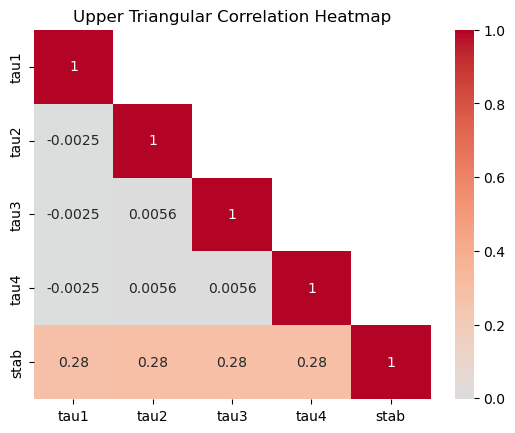

In [17]:
corr = df.loc[:,["tau1","tau2","tau3","tau4",'stab']].corr(numeric_only=True)
mask = np.tril(np.ones_like(corr, dtype=bool))
lower_corr = corr.where(mask)
# Plot heatmap with mask
#plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=~mask, annot=True, cmap='coolwarm', center=0)
plt.title("Upper Triangular Correlation Heatmap")
plt.show()

### SciPy’s Pearson correlation test:

### **Hypothesis Test :**

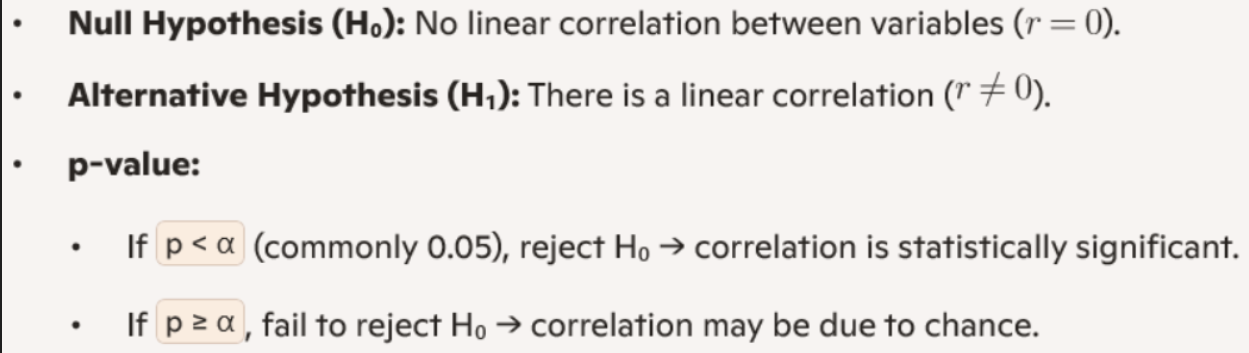

In [18]:
import itertools
alpha = 0.05
for (name1, arr1), (name2, arr2) in itertools.combinations(df.loc[:,["tau1","tau2","tau3","tau4",'stab']].items(), 2):
    corr_coff, p_value = pearsonr(arr1, arr2)
    print(f"correlations b/w {name1} vs {name2}: corr coff={corr_coff:.3f}, p_val={p_value:.3g}")
    if p_value < alpha:
        print(f"reject H₀ → correlation is statistically significant between {name1} & {name2}")
    if p_value >= alpha:
        print(f"fail to reject H₀ → correlation may be due to chance between {name1} & {name2}")

correlations b/w tau1 vs tau2: corr coff=-0.003, p_val=0.532
fail to reject H₀ → correlation may be due to chance between tau1 & tau2
correlations b/w tau1 vs tau3: corr coff=-0.003, p_val=0.532
fail to reject H₀ → correlation may be due to chance between tau1 & tau3
correlations b/w tau1 vs tau4: corr coff=-0.003, p_val=0.532
fail to reject H₀ → correlation may be due to chance between tau1 & tau4
correlations b/w tau1 vs stab: corr coff=0.276, p_val=0
reject H₀ → correlation is statistically significant between tau1 & stab
correlations b/w tau2 vs tau3: corr coff=0.006, p_val=0.174
fail to reject H₀ → correlation may be due to chance between tau2 & tau3
correlations b/w tau2 vs tau4: corr coff=0.006, p_val=0.174
fail to reject H₀ → correlation may be due to chance between tau2 & tau4
correlations b/w tau2 vs stab: corr coff=0.283, p_val=0
reject H₀ → correlation is statistically significant between tau2 & stab
correlations b/w tau3 vs tau4: corr coff=0.006, p_val=0.174
fail to reject

### Explaine Heatmap figure
1. Correlation between Response Functions (tau values)
- tau1 vs. tau2: +0.016 (Very weak positive correlation)
- tau1 vs. tau3: -0.006 (Negligible correlation)
- tau1 vs. tau4: -0.017 (Negligible correlation)

& we get same result from Null hypothesis test

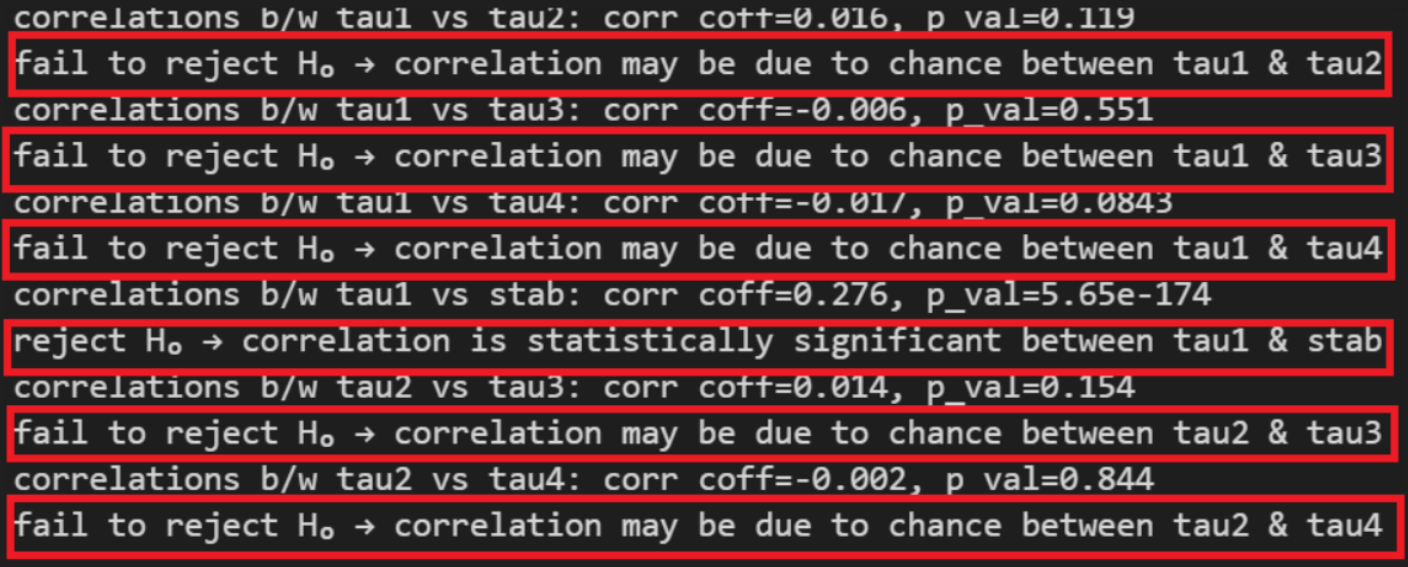

2. Correlation between Response Functions and Stability (stab)
- stab vs. tau1: +0.28 (Weak positive correlation)
- stab vs. tau2: +0.29 (Weak positive correlation)
- stab vs. tau3: +0.28 (Weak positive correlation)
- stab vs. tau4: +0.28 (Weak positive correlation)

The weak positive correlation suggests that as any single component's response time increases (higher ($\tau_{x}$)), the system's dominant eigenvalue tends to increase slightly, moving it incrementally toward a less stable state. However, because the correlations are only 0.28-0.29, no single response function is a strong predictor of stability on its own. The stability outcome depends on the combined effect and interactions of all variables.

### Examin lmplot between $\tau_{1}$ & stab categorized by the stability label stabf

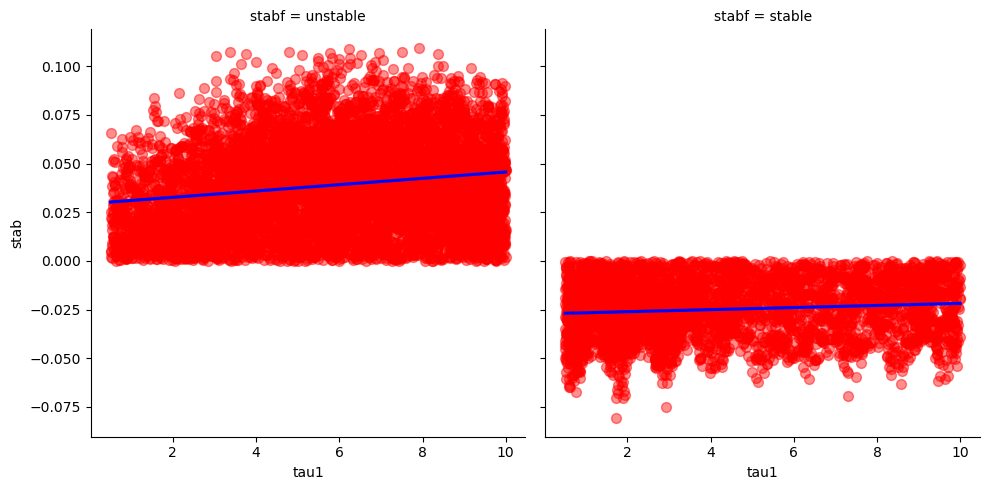

In [19]:
sns.lmplot(x="tau1", y="stab", data=df,col="stabf",
           scatter_kws={"color": "red","alpha":0.09, "s":50},
           line_kws={"color":"blue"}
)
plt.show()

- Left Plot (stabf = unstable): All data points have a positive stab value (above 0.0), ranging from approximately 0.0 to over 0.1.
- Right Plot (stabf = stable): All data points have a negative stab value (below 0.0), ranging from approximately -0.08 to 0.0.

**Slight Positive Correlation**: In both the stable and unstable datasets, the red line has a very slight positive slope. This indicates a weak positive correlation between $\tau_{1}$ and stab.

As the generator's response time constant ***$\tau_{1}$*** increases, the dominant eigenvalue (stab) tends to slightly increase (become less negative or more positive). This suggests that slower generator response times contribute marginally to reduced system stability.


## Examin correlation between coefficient (gamma) price elasticity & stab

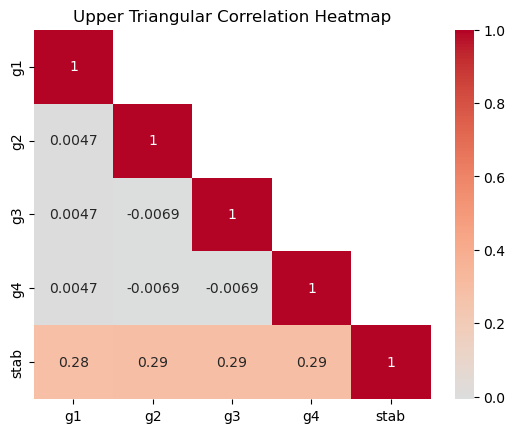

In [20]:
corr = df.loc[:,["g1","g2","g3","g4",'stab']].corr(numeric_only=True)
mask = np.tril(np.ones_like(corr, dtype=bool))
lower_corr = corr.where(mask)
# Plot heatmap with mask
#plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=~mask, annot=True, cmap='coolwarm', center=0)
plt.title("Upper Triangular Correlation Heatmap")
plt.show()

In [21]:
for (name1, arr1), (name2, arr2) in itertools.combinations(df.loc[:,["g1","g2","g3","g4",'stab']].items(), 2):
    corr_coff, p_value = pearsonr(arr1, arr2)
    print(f"correlations b/w {name1} vs {name2}: corr coff={corr_coff:.3f}, p_val={p_value:.3g}")
    if p_value < alpha:
        print(f"reject H₀ → correlation is statistically significant between {name1} & {name2}")
    if p_value >= alpha:
        print(f"fail to reject H₀ → correlation may be due to chance between {name1} & {name2}")

correlations b/w g1 vs g2: corr coff=0.005, p_val=0.248
fail to reject H₀ → correlation may be due to chance between g1 & g2
correlations b/w g1 vs g3: corr coff=0.005, p_val=0.248
fail to reject H₀ → correlation may be due to chance between g1 & g3
correlations b/w g1 vs g4: corr coff=0.005, p_val=0.248
fail to reject H₀ → correlation may be due to chance between g1 & g4
correlations b/w g1 vs stab: corr coff=0.283, p_val=0
reject H₀ → correlation is statistically significant between g1 & stab
correlations b/w g2 vs g3: corr coff=-0.007, p_val=0.0892
fail to reject H₀ → correlation may be due to chance between g2 & g3
correlations b/w g2 vs g4: corr coff=-0.007, p_val=0.0892
fail to reject H₀ → correlation may be due to chance between g2 & g4
correlations b/w g2 vs stab: corr coff=0.294, p_val=0
reject H₀ → correlation is statistically significant between g2 & stab
correlations b/w g3 vs g4: corr coff=-0.007, p_val=0.0892
fail to reject H₀ → correlation may be due to chance between g3

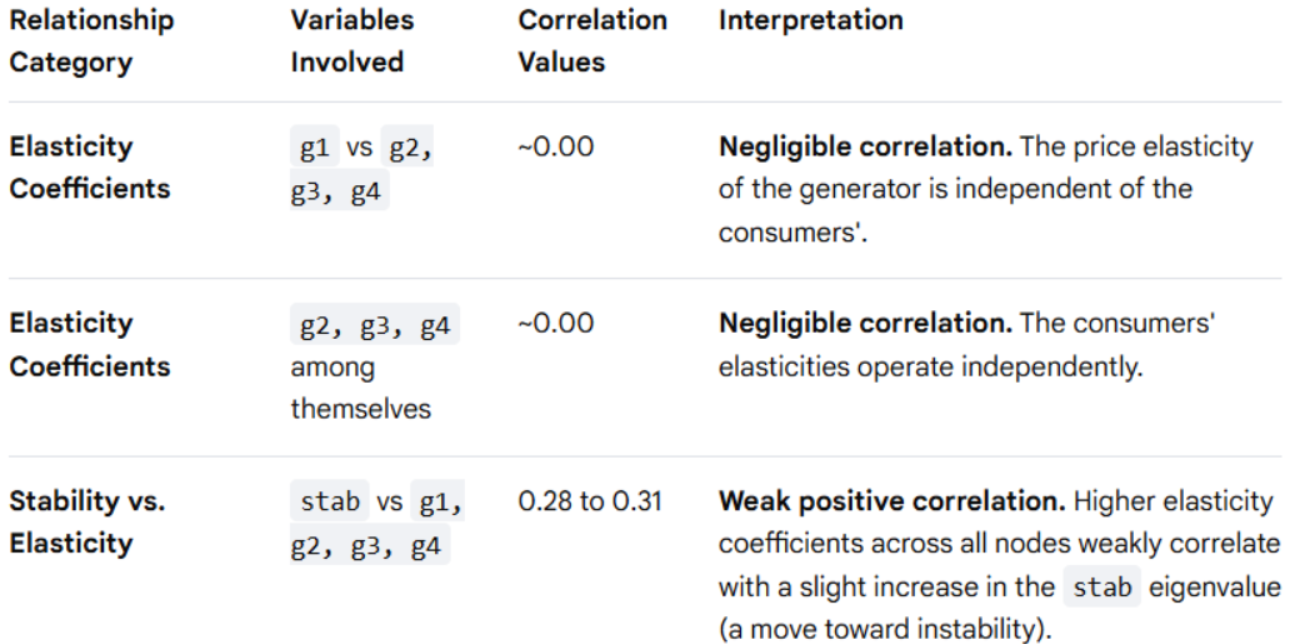

Same cthing we can found in null hypothesis test. we are faile to fail to reject H₀ b/w g1,g2,g3,g4. Whre a verry week correlation exixt bwtween another params.

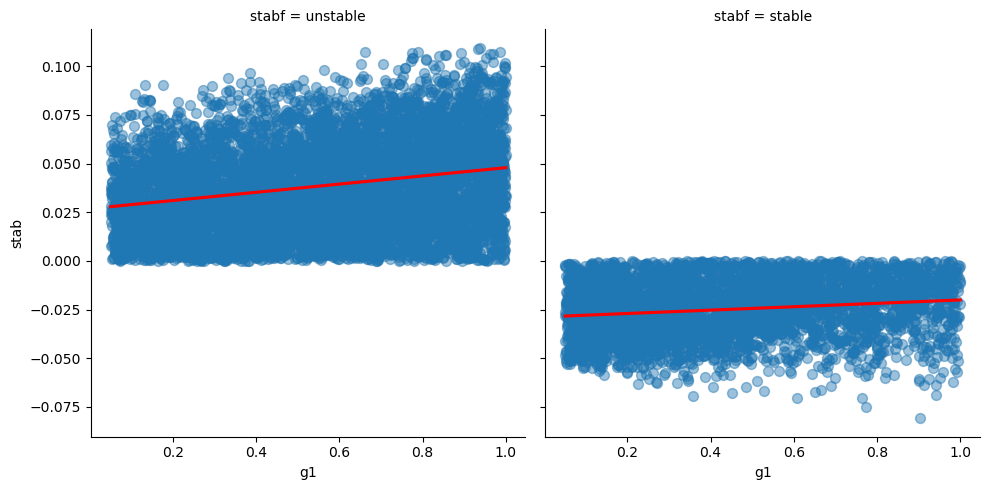

In [22]:
sns.lmplot(x="g1", y="stab", data=df,col="stabf",
           scatter_kws={"alpha":0.09, "s":50},
           line_kws={"color":"red"}
)
plt.show()

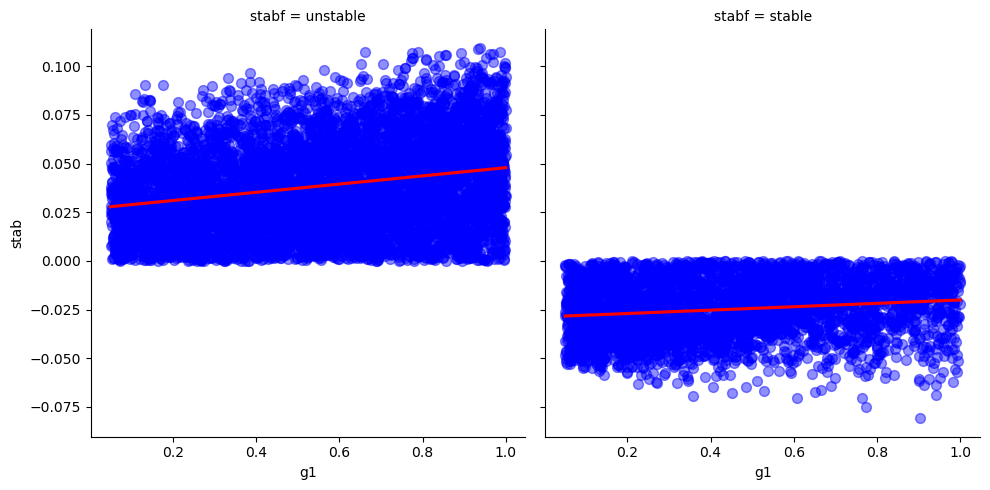

In [23]:
sns.lmplot(x="g1", y="stab", data=df,col="stabf",
           scatter_kws={"color": "blue","alpha":0.09, "s":50},
           line_kws={"color":"red"}
)
plt.show()

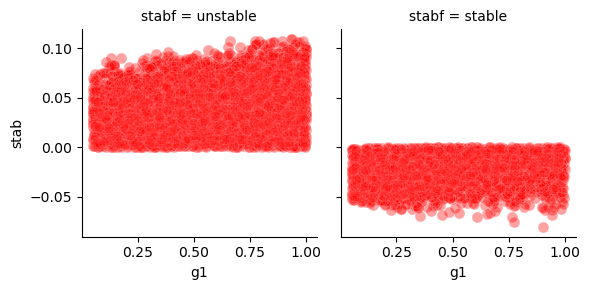

In [24]:
g = sns.FacetGrid(df, col="stabf")
g.map_dataframe(sns.scatterplot, x="g1", y="stab",color="red", alpha=0.07, s=60
)


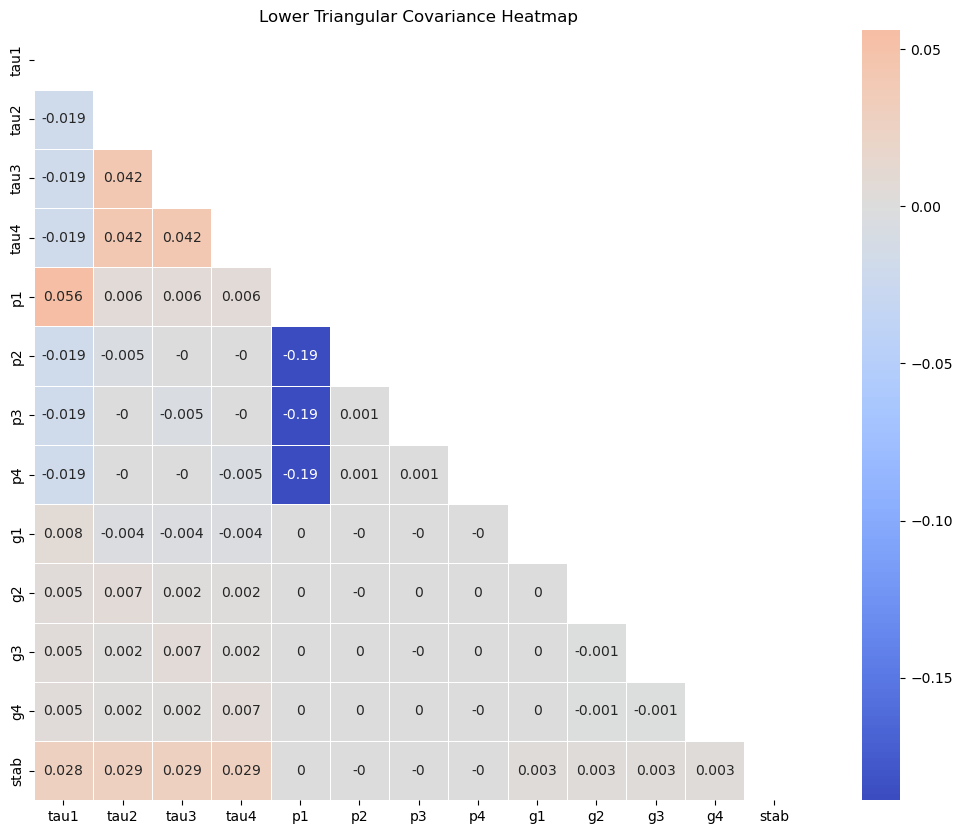

In [25]:
# Compute covariance matrix
cov = df.cov(numeric_only=True).round(decimals=3)
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(cov, dtype=bool))
# Plot heatmap with mask
plt.figure(figsize=(15,10))
sns.heatmap(
    cov,
    mask=mask,          # hide upper triangle
    annot=True,         # show covariance values
    cmap="coolwarm",    # color palette
    center=0,           # center colormap at zero
    square=True,        # square cells
    linewidths=0.5
)
plt.title("Lower Triangular Covariance Heatmap")
plt.show()

#### Get outlier in Dataset

In [26]:
# Calculate IQR
numeric_cols = df.select_dtypes(include='number').columns

# Function to detect outliers
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

# Apply to each numeric column
outlier_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    outlier_summary[col] = {
        'count': len(outliers),
        'indices': outliers.index.tolist()
    }

# Display summary
for col, info in outlier_summary.items():
    print(f"{col}: {info['count']} outliers → indices: {info['indices']}")

tau1: 0 outliers → indices: []
tau2: 0 outliers → indices: []
tau3: 0 outliers → indices: []
tau4: 0 outliers → indices: []
p1: 6 outliers → indices: [6273, 16273, 26273, 36273, 46273, 56273]
p2: 0 outliers → indices: []
p3: 0 outliers → indices: []
p4: 0 outliers → indices: []
g1: 0 outliers → indices: []
g2: 0 outliers → indices: []
g3: 0 outliers → indices: []
g4: 0 outliers → indices: []
stab: 0 outliers → indices: []


In [27]:
# Encode target variable (stable=1, unstable=0)
df['stabf'] = df['stabf'].map({'stable': 1, 'unstable': 0})
# Separate predictors and target
X = df.drop(columns=['stabf'])
y = df['stabf']
# Convert back to DataFrame for readability
X = pd.DataFrame(X, columns=X.columns)
print(X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Step 6: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab'],
      dtype='object')


#### Calculate the Variance Inflation Factor (VIF)

- VIF measures multicollinearity among predictors in regression.

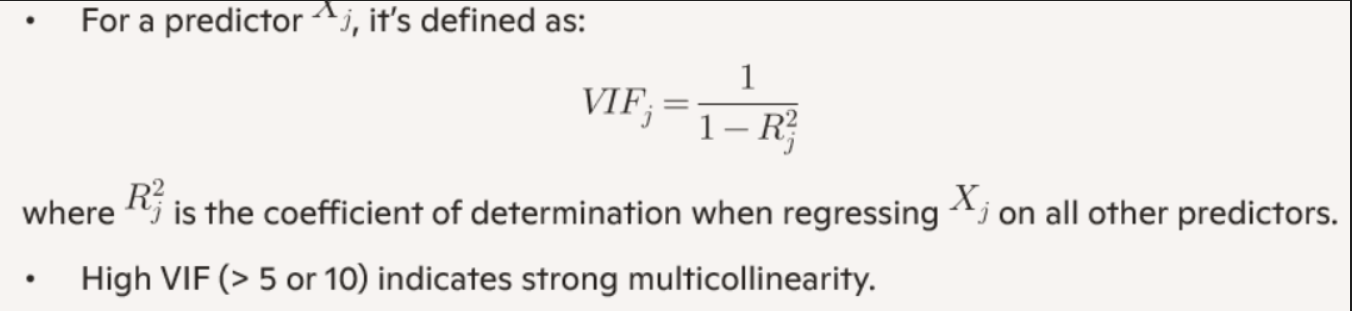

- Multicollinearity occurs when predictors are highly correlated, making it difficult to isolate their individual effects.
- High correlation → high $R^2$ → denominator 1-$R^2$ becomes small → VIF grows large.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Dropping power generator and receiver. This will cause error in code due to
# divide by zero.
vifX = X.drop(['p1','p2','p3','p4'],axis=1) 
# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = vifX.columns
vif_data["VIF"] = [variance_inflation_factor(vifX.values, i) for i in range(vifX.shape[1])]
print(vif_data)

  feature       VIF
0    tau1  4.123059
1    tau2  4.118914
2    tau3  4.118914
3    tau4  4.118914
4      g1  4.108450
5      g2  4.117689
6      g3  4.117689
7      g4  4.117689
8    stab  1.372370


#### Result Analysis

- VIF = 1 → No correlation with other predictors.
- VIF between 1–5 → Moderate correlation, usually acceptable.
- VIF > 5 (sometimes >10) → Strong multicollinearity, problematic for regression stability.

See Result

- Features like tau1–tau4 and g1–g4 have VIF ≈ 4 → moderate correlation, not extreme but worth monitoring.
- stab has VIF ≈ 1.37 → almost no multicollinearity.
- This suggests tau/g features are somewhat interrelated, but not dangerously so.



In [29]:
# Train Logistic Regression model
LogRegs_l2_liblinear = LogisticRegression(
                              C = 1.0, # Default
                              penalty='l2',
                              #l1_ratio=1, # Use with only elatice net
                              tol=0.0001, # Default
                              fit_intercept=True, # Const added in Models
                              solver='liblinear', # Default
                              max_iter=1000, # Default = 100
                              verbose=0 # Default 0
                              )
LogRegs_l2_liblinear.fit(X, y)
# Get Models Params
coef_series = pd.Series(
    [LogRegs_l2_liblinear.intercept_[0]] + list(LogRegs_l2_liblinear.coef_[0]),
    index=['Intercept'] + list(X.columns),
    name='Coefficient'
)

#### odds ratios
- Coefficients (β) are in log-odds, which are hard to interpret directly.
- Odds ratios (exp(β)) are intuitive: they show multiplicative changes in odds.
    - if OR > 1 : odds of outcome increse as xj increse (positive association)
    - if OR < 1 : odds of outcome reduces as xj increse (negative association)
    - if OR = 1 : No effect

In [30]:
# Log odds cofficient
coef = coef_series
# Get -ve log odds
coef_n = coef[coef < 0]
# OR of -ve Log odds
conf_exp = np.exp(coef_n)
dfOr = pd.DataFrame({'LogOdds':coef_n,'OR':np.round(conf_exp,3)},index = coef_n.index)
print('=============== OR for -Ve Log Odds negative association ========================')
print(dfOr)
coef_p = coef[coef > 0]
# OR of +ve Log odds
conf_exp = np.exp(coef_p)
dfOrPov = pd.DataFrame({'LogOdds':coef_p,'OR':np.round(conf_exp,3)},index = coef_p.index)
print('============== OR for +Ve Log Odds positive association ========================')
print(dfOrPov)

=============== OR for -Ve Log Odds negative association ========================
        LogOdds     OR
tau1  -0.124807  0.883
tau2  -0.127825  0.880
tau3  -0.127823  0.880
tau4  -0.127824  0.880
p1    -0.005565  0.994
g1    -0.782177  0.457
g2    -1.050043  0.350
g3    -1.048562  0.350
g4    -1.049617  0.350
stab -82.943485  0.000
============== OR for +Ve Log Odds positive association ========================
            LogOdds      OR
Intercept  4.386233  80.337
p2         0.001660   1.002
p3         0.001970   1.002
p4         0.001934   1.002
